In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os


load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [2]:
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-latest"
)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-latest', client=<google.genai.client.Client object at 0x0000020DE2C41960>, default_metadata=(), model_kwargs={})

In [3]:
llm.invoke("What is the capital of France?")

AIMessage(content=[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'Eq8BCqwBAb4+9vvCVg25R0Sd624PeZS5olKh/MhfsJ4Sch3vCV3euzG5vubkXZhUO4EtRAq96qRP+pHVuD1C1QT8AWn9+2inpgSmGJjz16XKzxcGcU5V4XWHNJlW+Imi/2/OCLEwRZmeECA8B0p2hvKVQZ8NYY8IP3TT6PGj3WIbGS35RNgr4FQOWgdjS9OwhwxFiMHox2/e+8rtuou/UUPbd5gHuAMRIoF2h1P9EUqBXQ=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d57b0-5241-73e0-8fd5-69a8645d8078-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 40, 'total_tokens': 48, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 32}})

In [5]:
#Pydantic Schema
from pydantic import BaseModel, Field

class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the message")
    post: str = Field(description="The content of the message")
    curated_post: str = Field(description="The curated content of the message")

demo_obj = graph_schema(
    topic="AI",
    post="AI is transforming the world.",
    curated_post="AI is revolutionizing various industries by automating tasks and providing insights."

)



In [ ]:
def create_post(state:graph_schema) -> graph_schema:
    state = state.model_dump()

    topic=state["topic"],

    post = llm.invoke(f"Write a linkedin post about {topic}").content

    state["post"] = post

    return state

def curate_post(state:graph_schema) -> graph_schema:
    state = state.model_dump()

    post=state["post"],

    post = llm.invoke(f"Write a linkedin post about {post}").content

    state["curated_post"] = curate_post
    return state

In [8]:
#Step 3: Create the State Graph
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

#Adding Nodes
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

#Adding Edges
graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()


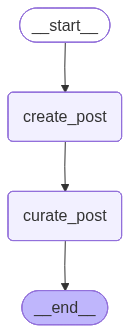

In [10]:
#Step 4 Compile the graph
from IPython.display import Image, display
first_graph = graph.compile()

Image(first_graph.get_graph().draw_mermaid_png())

In [11]:
pydantic_graph.invoke({
    "topic": "AI",
    "post": "",
    "curated_post": ""
})

UnboundLocalError: local variable 'topic' referenced before assignment